# 07 Cost-Sensitive XGBoost Tuning

This notebook tunes cost-sensitive XGBoost on top of a **selected fixed preprocessing variant**.

So this is not another preprocessing ablation. The feature engineering is already chosen first, then the model is tuned on top of that frozen feature set. The default starting point here is `v2_plus_missing_flags`, because that variant had the strongest earlier ROC-AUC in notebook `06`.

Business logic first:

- `false negative`: a real fraud case that the model misses
- `false positive`: a legitimate transaction that gets flagged and can still go through a confirmation or review step

That means it is reasonable to make fraud misses more costly. In this notebook that cost-sensitive behavior is implemented by increasing the effective positive-class weight through `scale_pos_weight`.

For comparability with notebook `06`, the split now happens on the full training data first. Only the training side is optionally downsampled for speed, while the validation side stays fixed on the full time-based holdout.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import shap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.cost_sensitive_experiments import (
    PRIMARY_METRIC,
    SECONDARY_METRICS,
    DIAGNOSTIC_METRICS,
    build_run_summary,
    build_shap_diagnostics,
    fit_cost_sensitive_xgboost,
    prepare_cost_sensitive_data,
    run_named_configs,
    run_weight_sweep,
)
from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

TRAIN_SAMPLE_SIZE = 80_000
RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 1_200
WEIGHT_MULTIPLIERS = [0.65, 0.75, 0.85]
VARIANT_CONFIGS = {
    "v2_plus_missing_flags": {
        "add_missing_indicators": True,
        "add_group_amount_features": False,
    },
    "v2_full": {
        "add_missing_indicators": True,
        "add_group_amount_features": True,
    },
}
SELECTED_VARIANT = "v2_plus_missing_flags"
SELECTED_VARIANT_CONFIG = VARIANT_CONFIGS[SELECTED_VARIANT]
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_STEM = f"cost_sensitive_{SELECTED_VARIANT}"


## Evaluation Setup

The notebook now prioritizes global discrimination first, while still keeping the fraud-capture ranking metrics visible for business review.

- `Primary metric`: `ROC-AUC`
- `Secondary metrics`: `Average Precision`, `Precision@Top3%`, `Recall@Top3%`
- `Diagnostics`: `Precision@Top1%`, `Precision@Top5%`


In [2]:
data_bundle = prepare_cost_sensitive_data(
    sample_size=TRAIN_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    variant_label=SELECTED_VARIANT,
    add_missing_indicators=SELECTED_VARIANT_CONFIG["add_missing_indicators"],
    add_group_amount_features=SELECTED_VARIANT_CONFIG["add_group_amount_features"],
)

run_summary = build_run_summary(data_bundle)
display(run_summary.style.hide(axis="index"))

print(f"Primary metric: {PRIMARY_METRIC}")
print(f"Secondary metrics: {', '.join(SECONDARY_METRICS)}")
print(f"Diagnostics: {', '.join(DIAGNOSTIC_METRICS)}")


item,value
variant_label,v2_plus_missing_flags
uses_missing_flags,True
uses_group_amount_features,False
split_strategy,full_time_split_then_sample_train_only
input_rows,590540
full_train_rows,472432
sampled_train_rows,80000
train_rows,80000
validation_rows,118108
train_fraud_rate,0.035162


Primary metric: roc_auc
Secondary metrics: average_precision, precision_at_top_3pct, recall_at_top_3pct
Diagnostics: precision_at_top_1pct, precision_at_top_5pct


## Untuned Baselines For The Selected Variant

Before tuning anything, it helps to pin down three reference points for the selected variant.

1. the earlier untuned baseline from notebook `06`
2. the same-split untuned non-cost-sensitive baseline inside this notebook
3. the same-split untuned cost-sensitive reference inside this notebook

That way the final conclusion can answer the question that matters most: after we start from the best setup found in notebook `06`, does adding cost sensitivity and tuning actually reduce missed fraud without hiding the original baseline?

Because the validation split is now the same full holdout used for comparison, the two in-notebook baselines can be read as a true apples-to-apples validation check rather than a sampled-validation proxy.


In [3]:
same_setup_params = {
    "n_estimators": 400,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "min_child_weight": 1,
    "reg_alpha": 0.0,
    "gamma": 0.0,
}

non_cost_reference_result = fit_cost_sensitive_xgboost(
    data_bundle,
    pos_weight_multiplier=1.0,
    label=f"{SELECTED_VARIANT}_same_split_non_cost_baseline",
    param_overrides={**same_setup_params, "scale_pos_weight": 1.0},
    return_artifacts=True,
)
cost_sensitive_reference_result = fit_cost_sensitive_xgboost(
    data_bundle,
    pos_weight_multiplier=1.0,
    label=f"{SELECTED_VARIANT}_cost_sensitive_reference_untuned",
    param_overrides=same_setup_params,
    return_artifacts=True,
)

non_cost_reference_row = non_cost_reference_result["row"]
cost_sensitive_reference_row = cost_sensitive_reference_result["row"]
display(
    pd.DataFrame([non_cost_reference_row, cost_sensitive_reference_row])[
        [
            "label",
            "roc_auc",
            "average_precision",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "precision_at_top_5pct",
            "recall_at_top_5pct",
            "precision",
            "recall",
            "f1",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

previous_v2_results_path = OUTPUT_DIR / "tree_ablation_v2_results.json"
previous_v2_results = None
previous_variant_row = None
if previous_v2_results_path.exists():
    previous_v2_results = pd.DataFrame(json.loads(previous_v2_results_path.read_text(encoding="utf-8")))
    display(previous_v2_results.style.hide(axis="index"))
    matched = previous_v2_results.loc[previous_v2_results["variant"] == SELECTED_VARIANT]
    if not matched.empty:
        previous_variant_row = matched.iloc[0].to_dict()
        earlier_baseline_display = pd.DataFrame(
            [
                {
                    "label": f"{SELECTED_VARIANT}_earlier_untuned_baseline",
                    "roc_auc": previous_variant_row["roc_auc"],
                    "average_precision": previous_variant_row["average_precision"],
                    "precision_at_top_5pct": previous_variant_row["precision_at_top_5pct"],
                    "recall_at_top_5pct": previous_variant_row["recall_at_top_5pct"],
                }
            ]
        )
        display(earlier_baseline_display.style.hide(axis="index"))


label,roc_auc,average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct,recall_at_top_5pct,precision,recall,f1,scale_pos_weight
v2_plus_missing_flags_same_split_non_cost_baseline,0.898377,0.512055,0.542043,0.472687,0.392821,0.570866,0.781197,0.337352,0.471215,1.000000
v2_plus_missing_flags_cost_sensitive_reference_untuned,0.888830,0.493116,0.522291,0.455463,0.375889,0.546260,0.301256,0.607776,0.402838,27.439389


variant,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct,n_features
v2_core,0.913423,0.550732,0.413548,0.600886,462
v2_plus_missing_flags,0.914340,0.552034,0.416427,0.605069,792
v2_full,0.911789,0.553101,0.412024,0.598671,807


label,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct
v2_plus_missing_flags_earlier_untuned_baseline,0.914340,0.552034,0.416427,0.605069


## Step 1: Narrow Cost-Sensitive Sweep

The first step only tunes the fraud-class weight. It does not touch the rest of the model capacity.

- `base_ratio = n_negative / n_positive`
- `scale_pos_weight = base_ratio * multiplier`
- the multiplier is applied to the positive fraud class weight, not used as a raw class weight

Here the notebook checks `0.65`, `0.75`, and `0.85`.


label,pos_weight_multiplier,scale_pos_weight,roc_auc,average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_1pct,precision_at_top_5pct
weight_x0.75,0.750000,20.579541,0.893216,0.495496,0.521445,0.454724,0.852792,0.380461
weight_x0.65,0.650000,17.835603,0.893076,0.499508,0.529063,0.461368,0.861252,0.386725
weight_x0.85,0.850000,23.323480,0.890662,0.492683,0.522856,0.455955,0.860406,0.380122


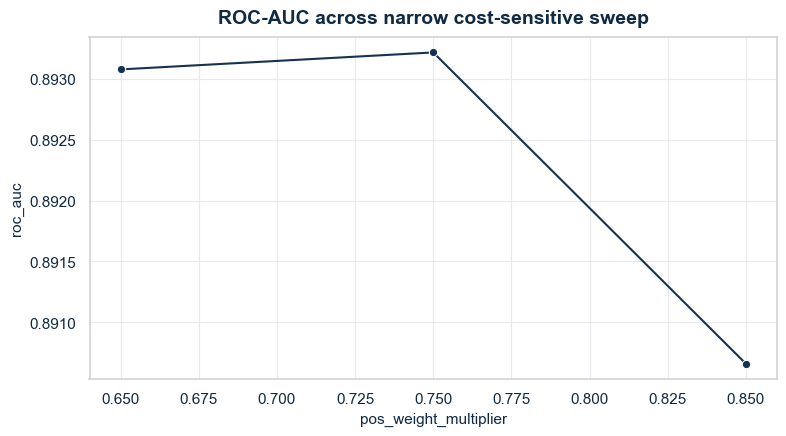

In [4]:
weight_results, weight_artifacts = run_weight_sweep(
    data_bundle,
    multipliers=WEIGHT_MULTIPLIERS,
)

previous_weight_reference = None
if SELECTED_VARIANT == "v2_full":
    previous_weight_reference = pd.DataFrame(
        [
            {
                "label": "previous_weight_x0.6",
                "pos_weight_multiplier": 0.6,
                "scale_pos_weight": 16.271705,
                "precision_at_top_3pct": 0.522917,
                "recall_at_top_3pct": 0.439580,
                "average_precision": 0.480077,
                "precision_at_top_1pct": 0.812500,
                "precision_at_top_5pct": 0.393750,
                "roc_auc": 0.892649,
            }
        ]
    )

weight_display = (
    pd.concat([previous_weight_reference, weight_results], ignore_index=True, sort=False)
    if previous_weight_reference is not None
    else weight_results.copy()
)

display(
    weight_display[
        [
            "label",
            "pos_weight_multiplier",
            "scale_pos_weight",
            "roc_auc",
            "average_precision",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
        ]
    ].style.hide(axis="index")
)

best_weight_row = weight_results.iloc[0]
best_weight_multiplier = float(best_weight_row["pos_weight_multiplier"])

plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=weight_results.sort_values("pos_weight_multiplier"),
    x="pos_weight_multiplier",
    y="roc_auc",
    marker="o",
    color=PLOT_COLORS["navy"],
)
if previous_weight_reference is not None:
    plt.axhline(
        previous_weight_reference.loc[0, "roc_auc"],
        linestyle="--",
        color=PLOT_COLORS["muted"],
        linewidth=1,
        label="previous 0.6 reference",
    )
plt.title("ROC-AUC across narrow cost-sensitive sweep")
plt.xlabel("pos_weight_multiplier")
plt.ylabel("roc_auc")
if previous_weight_reference is not None:
    plt.legend()
plt.tight_layout()
plt.show()


## Step 2: Targeted Hyperparameter Search

After the weight sweep, keep the best positive-class multiplier fixed and compare a compact set of XGBoost configurations around model capacity, sampling, and regularization.

All metrics stay visible. The notebook keeps the ROC-AUC ranking, but it also names a separate business-first winner using threshold-0.5 fraud recall as the main priority because missed fraud is more costly than extra fraud flags.


label,roc_auc,average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_1pct,precision_at_top_5pct,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,gamma,scale_pos_weight
deeper_depth8_lr03_700,0.896751,0.517421,0.549379,0.479085,0.873096,0.393159,700,8,0.030000,0.800000,0.700000,3.000000,2.000000,0.100000,0.000000,20.579541
regularized_depth6_lambda5,0.896734,0.501577,0.525113,0.457923,0.859560,0.383000,700,6,0.030000,0.800000,0.700000,5.000000,5.000000,0.100000,0.000000,20.579541
more_capacity_depth7_lr03_800,0.894892,0.514071,0.540914,0.471703,0.873942,0.390958,800,7,0.030000,0.800000,0.700000,3.000000,2.000000,0.100000,0.000000,20.579541
conservative_sampling_depth5,0.894490,0.495392,0.520598,0.453986,0.859560,0.381307,700,5,0.030000,0.700000,0.600000,5.000000,5.000000,0.100000,0.000000,20.579541
strong_regularization_depth5,0.894469,0.501941,0.527652,0.460138,0.858714,0.388419,600,5,0.050000,0.850000,0.800000,8.000000,10.000000,0.500000,0.500000,20.579541
balanced_depth6_lr05_500,0.893548,0.503603,0.530474,0.462598,0.865482,0.385032,500,6,0.050000,0.800000,0.800000,5.000000,2.000000,0.000000,0.000000,20.579541
wide_sampling_depth7_lr03_800,0.892816,0.511660,0.542325,0.472933,0.872250,0.391466,800,7,0.030000,0.850000,0.850000,3.000000,2.000000,0.100000,0.000000,20.579541
precision_push_depth4_lr08,0.892310,0.487135,0.515237,0.449311,0.850254,0.376905,450,4,0.080000,0.700000,0.600000,8.000000,5.000000,1.000000,1.000000,20.579541


label,recall,precision,f1,roc_auc,average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct
conservative_sampling_depth5,0.650591,0.271542,0.383161,0.894490,0.495392,0.520598,0.453986,0.381307
precision_push_depth4_lr08,0.635089,0.278005,0.386725,0.892310,0.487135,0.515237,0.449311,0.376905
strong_regularization_depth5,0.621555,0.303861,0.408176,0.894469,0.501941,0.527652,0.460138,0.388419
regularized_depth6_lambda5,0.601132,0.323919,0.420989,0.896734,0.501577,0.525113,0.457923,0.383000
balanced_depth6_lr05_500,0.568652,0.376507,0.453048,0.893548,0.503603,0.530474,0.462598,0.385032
more_capacity_depth7_lr03_800,0.516240,0.477035,0.495864,0.894892,0.514071,0.540914,0.471703,0.390958
wide_sampling_depth7_lr03_800,0.513041,0.471719,0.491513,0.892816,0.511660,0.542325,0.472933,0.391466
deeper_depth8_lr03_700,0.480561,0.546141,0.511257,0.896751,0.517421,0.549379,0.479085,0.393159


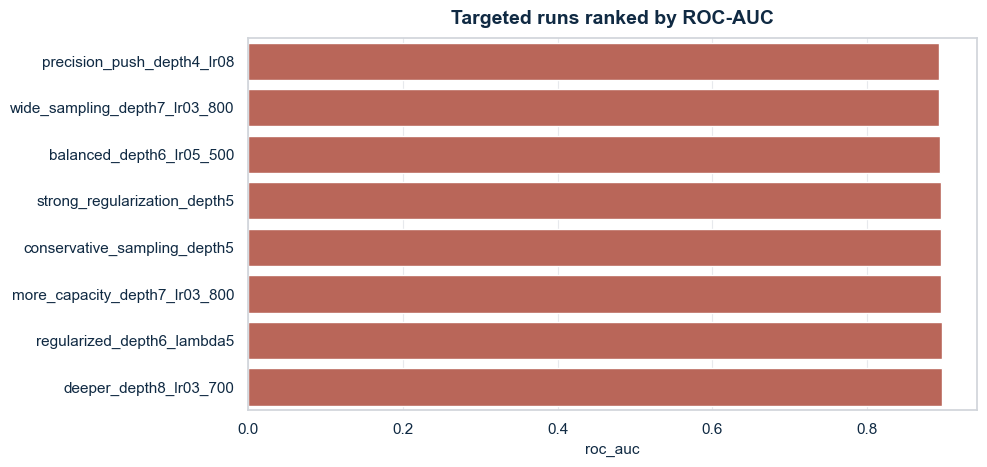

In [5]:
tuning_blueprint = [
    ("balanced_depth6_lr05_500", 500, 6, 0.05, 0.80, 0.80, 5, 2.0, 0.0, 0.0),
    ("more_capacity_depth7_lr03_800", 800, 7, 0.03, 0.80, 0.70, 3, 2.0, 0.1, 0.0),
    ("deeper_depth8_lr03_700", 700, 8, 0.03, 0.80, 0.70, 3, 2.0, 0.1, 0.0),
    ("wide_sampling_depth7_lr03_800", 800, 7, 0.03, 0.85, 0.85, 3, 2.0, 0.1, 0.0),
    ("regularized_depth6_lambda5", 700, 6, 0.03, 0.80, 0.70, 5, 5.0, 0.1, 0.0),
    ("strong_regularization_depth5", 600, 5, 0.05, 0.85, 0.80, 8, 10.0, 0.5, 0.5),
    ("conservative_sampling_depth5", 700, 5, 0.03, 0.70, 0.60, 5, 5.0, 0.1, 0.0),
    ("precision_push_depth4_lr08", 450, 4, 0.08, 0.70, 0.60, 8, 5.0, 1.0, 1.0),
]

targeted_configs = [
    {
        "label": label,
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "min_child_weight": min_child_weight,
            "reg_lambda": reg_lambda,
            "reg_alpha": reg_alpha,
            "gamma": gamma,
        },
    }
    for (
        label,
        n_estimators,
        max_depth,
        learning_rate,
        subsample,
        colsample_bytree,
        min_child_weight,
        reg_lambda,
        reg_alpha,
        gamma,
    ) in tuning_blueprint
]

targeted_results, targeted_artifacts = run_named_configs(
    data_bundle,
    configs=targeted_configs,
)

display(
    targeted_results[
        [
            "label",
            "roc_auc",
            "average_precision",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "min_child_weight",
            "reg_lambda",
            "reg_alpha",
            "gamma",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

best_targeted_row = targeted_results.iloc[0]
best_targeted_result = targeted_artifacts[best_targeted_row["label"]]

business_targeted_results = targeted_results.sort_values(
    ["recall", "precision", "f1", "roc_auc", "average_precision"],
    ascending=False,
).reset_index(drop=True)
best_business_row = business_targeted_results.iloc[0]
best_business_result = targeted_artifacts[best_business_row["label"]]
final_selected_row = best_business_row
final_selected_result = best_business_result

display(
    business_targeted_results[
        [
            "label",
            "recall",
            "precision",
            "f1",
            "roc_auc",
            "average_precision",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "precision_at_top_5pct",
        ]
    ].style.hide(axis="index")
)

plt.figure(figsize=(10, 4.8))
sns.barplot(
    data=targeted_results.iloc[::-1],
    x="roc_auc",
    y="label",
    color=PLOT_COLORS["coral"],
)
plt.title("Targeted runs ranked by ROC-AUC")
plt.xlabel("roc_auc")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Final Comparison: Original Baseline, Cost-Sensitive Increment, And Tuned Winners

This is the most important summary view in the notebook. It keeps the original baseline visible, then shows what changes after adding cost sensitivity, and finally compares the ROC-AUC winner with the business-first winner.


model,roc_auc,average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct,recall_at_top_5pct,precision,recall,f1,scale_pos_weight
06 earlier baseline,0.914340,0.552034,nan,nan,0.416427,0.605069,nan,nan,nan,nan
07 non-cost baseline,0.898377,0.512055,0.542043,0.472687,0.392821,0.570866,0.781197,0.337352,0.471215,1.000000
07 cost-sensitive ref,0.888830,0.493116,0.522291,0.455463,0.375889,0.546260,0.301256,0.607776,0.402838,27.439389
07 ROC-AUC winner,0.896751,0.517421,0.549379,0.479085,0.393159,0.571358,0.546141,0.480561,0.511257,20.579541
07 business winner,0.894490,0.495392,0.520598,0.453986,0.381307,0.554134,0.271542,0.650591,0.383161,20.579541


comparison,roc_auc,average_precision,precision,recall,f1,precision_at_top_5pct,recall_at_top_5pct
cost_sensitive_reference_minus_same_split_non_cost_baseline,-0.009547,-0.018939,-0.479940,0.270423,-0.068377,-0.016932,-0.024606


comparison,roc_auc,average_precision,precision,recall,f1,precision_at_top_5pct,recall_at_top_5pct
business_winner_minus_same_split_non_cost_baseline,-0.003887,-0.016663,-0.509655,0.313238,-0.088054,-0.011514,-0.016732


comparison,roc_auc,average_precision,precision,recall,f1,precision_at_top_5pct,recall_at_top_5pct
business_winner_minus_cost_sensitive_reference,0.005660,0.002276,-0.029715,0.042815,-0.019677,0.005418,0.007874


comparison,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct
business_winner_minus_earlier_untuned_baseline,-0.019850,-0.056642,-0.035120,-0.050935


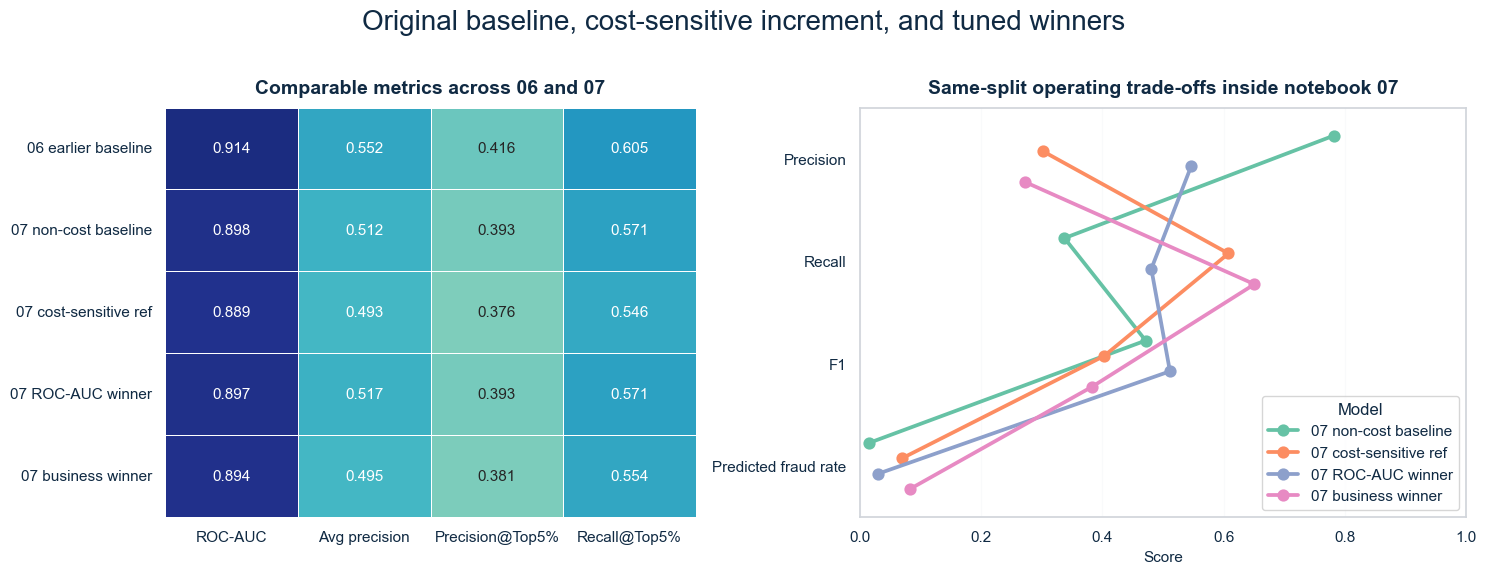

In [6]:
comparison_rows = []
if previous_variant_row is not None:
    comparison_rows.append(
        {
            "label": f"{SELECTED_VARIANT}_earlier_untuned_baseline",
            "roc_auc": previous_variant_row["roc_auc"],
            "average_precision": previous_variant_row["average_precision"],
            "precision_at_top_5pct": previous_variant_row["precision_at_top_5pct"],
            "recall_at_top_5pct": previous_variant_row["recall_at_top_5pct"],
        }
    )

comparison_rows.extend(
    [
        non_cost_reference_row,
        cost_sensitive_reference_row,
        best_targeted_result["row"],
        final_selected_result["row"],
    ]
)

final_comparison = pd.DataFrame(comparison_rows)
label_display_map = {
    f"{SELECTED_VARIANT}_earlier_untuned_baseline": "06 earlier baseline",
    non_cost_reference_row["label"]: "07 non-cost baseline",
    cost_sensitive_reference_row["label"]: "07 cost-sensitive ref",
    best_targeted_row["label"]: "07 ROC-AUC winner",
    final_selected_row["label"]: "07 business winner",
}
final_comparison["model"] = final_comparison["label"].map(label_display_map).fillna(final_comparison["label"])

display(
    final_comparison[
        [
            "model",
            "roc_auc",
            "average_precision",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "precision_at_top_5pct",
            "recall_at_top_5pct",
            "precision",
            "recall",
            "f1",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

delta_cost_sensitive_vs_non_cost = {
    "comparison": "cost_sensitive_reference_minus_same_split_non_cost_baseline",
    "roc_auc": cost_sensitive_reference_row["roc_auc"] - non_cost_reference_row["roc_auc"],
    "average_precision": cost_sensitive_reference_row["average_precision"] - non_cost_reference_row["average_precision"],
    "precision": cost_sensitive_reference_row["precision"] - non_cost_reference_row["precision"],
    "recall": cost_sensitive_reference_row["recall"] - non_cost_reference_row["recall"],
    "f1": cost_sensitive_reference_row["f1"] - non_cost_reference_row["f1"],
    "precision_at_top_5pct": cost_sensitive_reference_row["precision_at_top_5pct"] - non_cost_reference_row["precision_at_top_5pct"],
    "recall_at_top_5pct": cost_sensitive_reference_row["recall_at_top_5pct"] - non_cost_reference_row["recall_at_top_5pct"],
}
display(pd.DataFrame([delta_cost_sensitive_vs_non_cost]).style.hide(axis="index"))

delta_business_vs_non_cost = {
    "comparison": "business_winner_minus_same_split_non_cost_baseline",
    "roc_auc": final_selected_result["row"]["roc_auc"] - non_cost_reference_row["roc_auc"],
    "average_precision": final_selected_result["row"]["average_precision"] - non_cost_reference_row["average_precision"],
    "precision": final_selected_result["row"]["precision"] - non_cost_reference_row["precision"],
    "recall": final_selected_result["row"]["recall"] - non_cost_reference_row["recall"],
    "f1": final_selected_result["row"]["f1"] - non_cost_reference_row["f1"],
    "precision_at_top_5pct": final_selected_result["row"]["precision_at_top_5pct"] - non_cost_reference_row["precision_at_top_5pct"],
    "recall_at_top_5pct": final_selected_result["row"]["recall_at_top_5pct"] - non_cost_reference_row["recall_at_top_5pct"],
}
display(pd.DataFrame([delta_business_vs_non_cost]).style.hide(axis="index"))

delta_business_vs_cost_sensitive_reference = {
    "comparison": "business_winner_minus_cost_sensitive_reference",
    "roc_auc": final_selected_result["row"]["roc_auc"] - cost_sensitive_reference_row["roc_auc"],
    "average_precision": final_selected_result["row"]["average_precision"] - cost_sensitive_reference_row["average_precision"],
    "precision": final_selected_result["row"]["precision"] - cost_sensitive_reference_row["precision"],
    "recall": final_selected_result["row"]["recall"] - cost_sensitive_reference_row["recall"],
    "f1": final_selected_result["row"]["f1"] - cost_sensitive_reference_row["f1"],
    "precision_at_top_5pct": final_selected_result["row"]["precision_at_top_5pct"] - cost_sensitive_reference_row["precision_at_top_5pct"],
    "recall_at_top_5pct": final_selected_result["row"]["recall_at_top_5pct"] - cost_sensitive_reference_row["recall_at_top_5pct"],
}
display(pd.DataFrame([delta_business_vs_cost_sensitive_reference]).style.hide(axis="index"))

delta_business_vs_earlier_baseline = None
if previous_variant_row is not None:
    delta_business_vs_earlier_baseline = {
        "comparison": "business_winner_minus_earlier_untuned_baseline",
        "roc_auc": final_selected_result["row"]["roc_auc"] - previous_variant_row["roc_auc"],
        "average_precision": final_selected_result["row"]["average_precision"] - previous_variant_row["average_precision"],
        "precision_at_top_5pct": final_selected_result["row"]["precision_at_top_5pct"] - previous_variant_row["precision_at_top_5pct"],
        "recall_at_top_5pct": final_selected_result["row"]["recall_at_top_5pct"] - previous_variant_row["recall_at_top_5pct"],
    }
    display(pd.DataFrame([delta_business_vs_earlier_baseline]).style.hide(axis="index"))

comparable_metric_labels = {
    "roc_auc": "ROC-AUC",
    "average_precision": "Avg precision",
    "precision_at_top_5pct": "Precision@Top5%",
    "recall_at_top_5pct": "Recall@Top5%",
}
comparable_metrics = list(comparable_metric_labels)
comparison_heatmap = final_comparison.set_index("model")[comparable_metrics].rename(columns=comparable_metric_labels)

same_split_operating_metrics = [
    "precision",
    "recall",
    "f1",
    "positive_prediction_rate",
]
same_split_models = final_comparison[final_comparison["model"] != "06 earlier baseline"].copy()
operating_plot = same_split_models.melt(
    id_vars="model",
    value_vars=same_split_operating_metrics,
    var_name="metric",
    value_name="value",
).replace(
    {
        "metric": {
            "precision": "Precision",
            "recall": "Recall",
            "f1": "F1",
            "positive_prediction_rate": "Predicted fraud rate",
        }
    }
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={"width_ratios": [1.05, 1.2]})
sns.heatmap(
    comparison_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Comparable metrics across 06 and 07")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.pointplot(
    data=operating_plot,
    x="value",
    y="metric",
    hue="model",
    dodge=0.45,
    markers="o",
    linestyles="-",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Same-split operating trade-offs inside notebook 07")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)
axes[1].grid(axis="x", alpha=0.2)
axes[1].legend(title="Model", loc="lower right", frameon=True)

fig.suptitle("Original baseline, cost-sensitive increment, and tuned winners", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


## SHAP For The Final Selected Model

This section keeps a compact global SHAP summary, adds a mean-absolute SHAP bar chart, and includes one local waterfall view for a high-risk validation row.


item,value
selected_variant,v2_plus_missing_flags
best_weight_label,weight_x0.75
roc_auc_winner_label,deeper_depth8_lr03_700
business_winner_label,conservative_sampling_depth5
rows_used_for_shap,1200
top_feature_for_dependence_view,card6__count


feature,mean_abs_shap
card6__count,0.215073
V29,0.172278
TransactionAmt,0.169536
C14,0.165654
C1,0.156579
C13,0.150871
D2,0.138640
C11,0.112918
card1,0.111944
P_emaildomain__count,0.108004


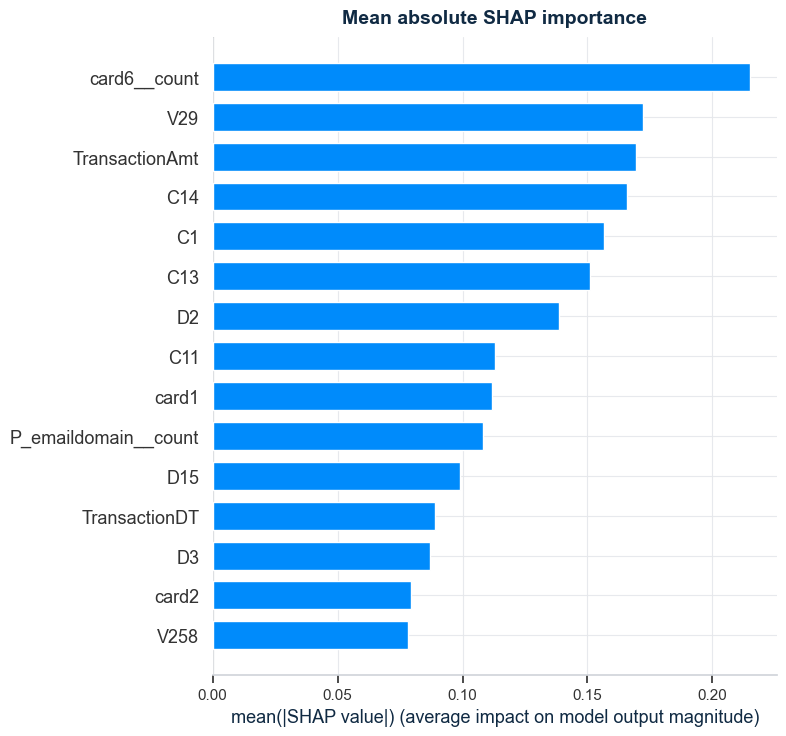

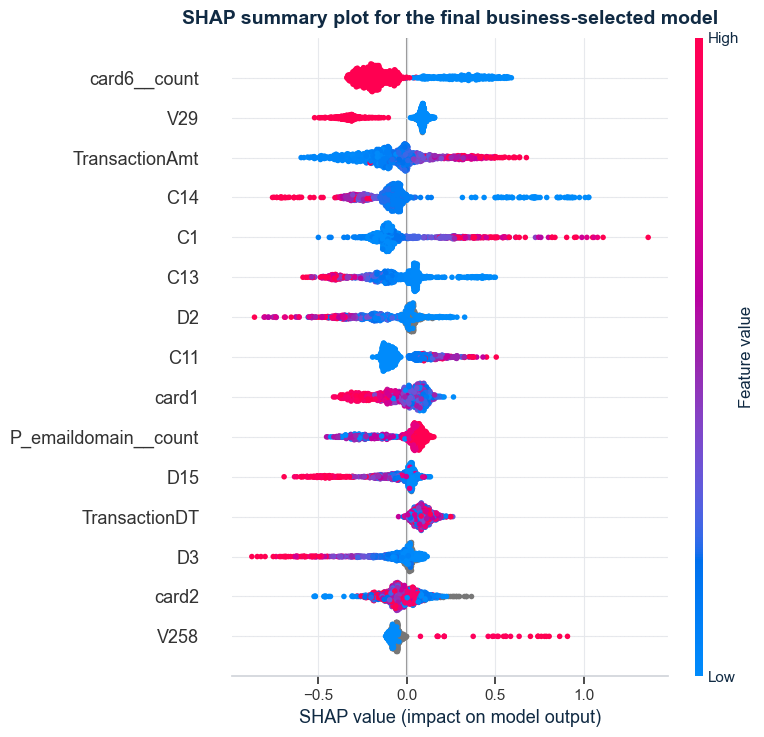

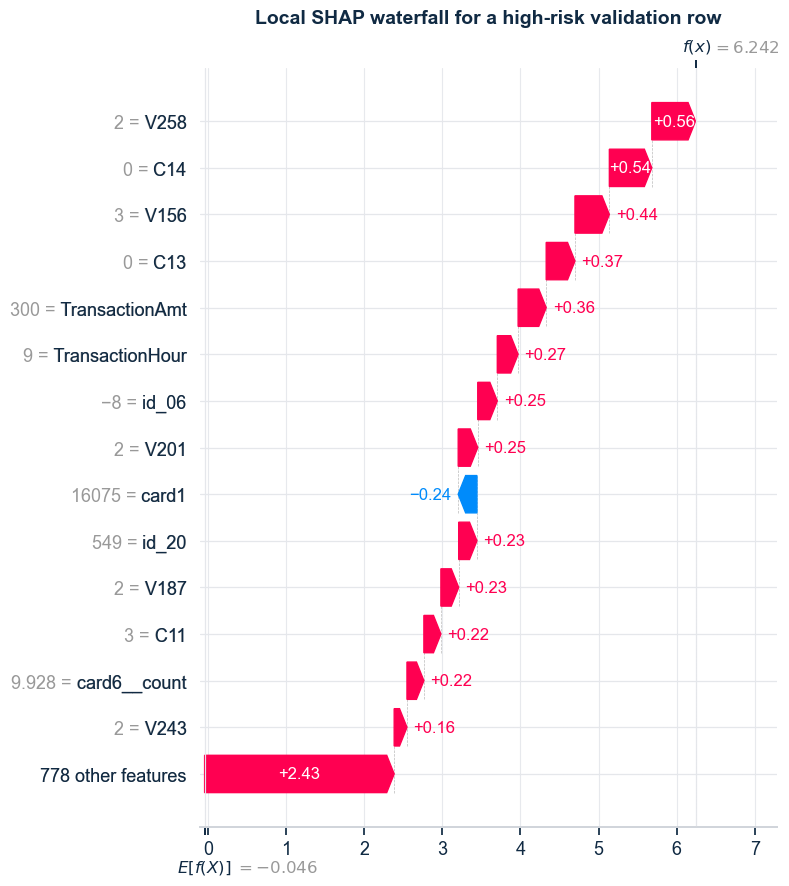

In [7]:
shap_pack = build_shap_diagnostics(
    final_selected_result["model"],
    data_bundle.x_valid,
    data_bundle.y_valid,
    sample_size=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

display(
    pd.DataFrame(
        [
            {"item": "selected_variant", "value": SELECTED_VARIANT},
            {"item": "best_weight_label", "value": best_weight_row["label"]},
            {"item": "roc_auc_winner_label", "value": best_targeted_row["label"]},
            {"item": "business_winner_label", "value": final_selected_row["label"]},
            {"item": "rows_used_for_shap", "value": shap_pack["row_count"]},
            {"item": "top_feature_for_dependence_view", "value": shap_pack["top_feature"]},
        ]
    ).style.hide(axis="index")
)

display(shap_pack["importance"].style.hide(axis="index"))

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_pack["shap_matrix"],
    shap_pack["x_sample"],
    plot_type="bar",
    show=False,
    max_display=15,
)
plt.title("Mean absolute SHAP importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_pack["shap_matrix"],
    shap_pack["x_sample"],
    show=False,
    max_display=15,
)
plt.title("SHAP summary plot for the final business-selected model")
plt.tight_layout()
plt.show()

valid_score_series = pd.Series(final_selected_result["valid_scores"], index=data_bundle.x_valid.index)
sample_scores = valid_score_series.loc[shap_pack["x_sample"].index]
local_row_position = int(sample_scores.to_numpy().argmax())

local_explanation = shap.Explanation(
    values=shap_pack["shap_matrix"][local_row_position],
    base_values=shap_pack["expected_value"],
    data=shap_pack["x_sample"].iloc[local_row_position].to_numpy(),
    feature_names=shap_pack["x_sample"].columns.tolist(),
)

shap.plots.waterfall(local_explanation, max_display=15, show=False)
plt.title("Local SHAP waterfall for a high-risk validation row")
plt.tight_layout()
plt.show()


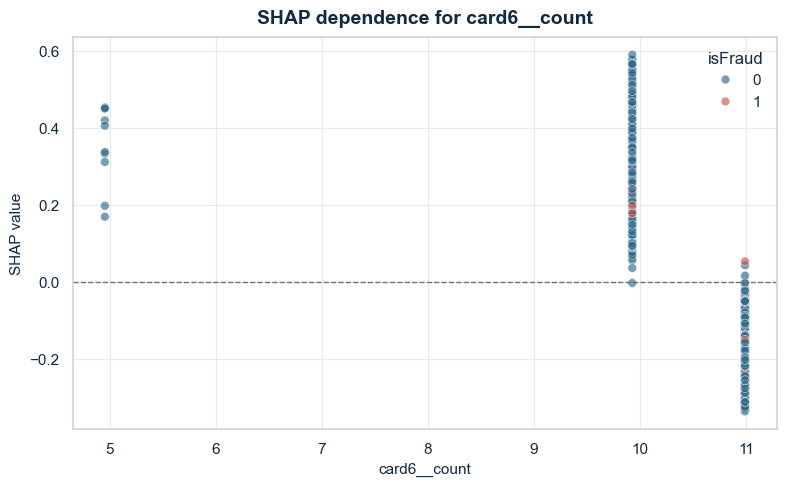

In [8]:
dependence_frame = shap_pack["dependence_frame"]
plt.figure(figsize=(8, 5))
if dependence_frame.empty:
    plt.text(0.5, 0.5, "No usable numeric values were available for the dependence view.", ha="center", va="center", wrap=True)
    plt.axis("off")
else:
    sns.scatterplot(
        data=dependence_frame,
        x=shap_pack["top_feature"],
        y="shap_value",
        hue="isFraud",
        palette={0: PLOT_COLORS["blue"], 1: PLOT_COLORS["coral"]},
        alpha=0.65,
        s=40,
    )
    plt.axhline(0, linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
    plt.title(f"SHAP dependence for {shap_pack['top_feature']}")
    plt.xlabel(shap_pack["top_feature"])
    plt.ylabel("SHAP value")
    plt.legend(title="isFraud")
plt.tight_layout()
plt.show()


In [9]:
weight_results.to_csv(OUTPUT_DIR / "cost_sensitive_weight_sweep.csv", index=False)
targeted_results.to_csv(OUTPUT_DIR / "cost_sensitive_targeted_runs.csv", index=False)
weight_results.to_csv(OUTPUT_DIR / f"{OUTPUT_STEM}_weight_sweep.csv", index=False)
targeted_results.to_csv(OUTPUT_DIR / f"{OUTPUT_STEM}_targeted_runs.csv", index=False)

summary_payload = {
    "selected_variant": SELECTED_VARIANT,
    "previous_baseline_run": previous_variant_row,
    "same_split_non_cost_baseline": non_cost_reference_row,
    "cost_sensitive_reference_run": cost_sensitive_reference_row,
    "best_weight_run": best_weight_row.to_dict(),
    "best_roc_auc_tuned_run": best_targeted_row.to_dict(),
    "best_business_tuned_run": final_selected_row.to_dict(),
    "delta_cost_sensitive_vs_non_cost": delta_cost_sensitive_vs_non_cost,
    "delta_business_vs_non_cost": delta_business_vs_non_cost,
    "delta_business_vs_cost_sensitive_reference": delta_business_vs_cost_sensitive_reference,
    "delta_business_vs_earlier_baseline": delta_business_vs_earlier_baseline,
}
(OUTPUT_DIR / "cost_sensitive_tuning_summary.json").write_text(
    json.dumps(summary_payload, indent=2),
    encoding="utf-8",
)
(OUTPUT_DIR / f"{OUTPUT_STEM}_summary.json").write_text(
    json.dumps(summary_payload, indent=2),
    encoding="utf-8",
)

print("Saved outputs/cost_sensitive_weight_sweep.csv")
print("Saved outputs/cost_sensitive_targeted_runs.csv")
print("Saved outputs/cost_sensitive_tuning_summary.json")


Saved outputs/cost_sensitive_weight_sweep.csv
Saved outputs/cost_sensitive_targeted_runs.csv
Saved outputs/cost_sensitive_tuning_summary.json


## Reading The Result

Use the comparison above to answer three separate questions:

- what happens when we add cost sensitivity without changing the rest of the setup?
- which tuned run wins on `ROC-AUC`?
- which tuned run is better for the business preference of reducing missed fraud, even if that means more fraud flags?

This notebook now defaults to `v2_plus_missing_flags` because that variant had the strongest earlier ROC-AUC among the preprocessing choices, but the final business-selected model is chosen with fraud recall as the main priority while all metrics stay visible.


## Confusion Matrix And Threshold Review For The Business-Selected Final Model

This final view shows the confusion matrix for the business-selected tuned winner using a default probability threshold of `0.5` on the same full validation holdout used throughout the notebook.

To match the fraud-review business view, class `1` means `fraud` and the matrix is ordered with `TP` in the top-left corner.

A compact threshold sweep is also included so we can see what happens if the cost-sensitive model uses a stricter fraud threshold to reduce false positives.


item,value
model,conservative_sampling_depth5
positive_class,1 = fraud
threshold,0.500000
true_negative,106951
false_positive,7093
false_negative,1420
true_positive,2644


threshold,true_positive,false_negative,false_positive,true_negative,recall,precision,false_positive_rate,predicted_fraud_rate
0.500000,2644,1420,7093,106951,0.650591,0.271542,0.062195,0.082441


,pred_fraud_1,pred_nonfraud_0
actual_fraud_1,2644,1420
actual_nonfraud_0,7093,106951


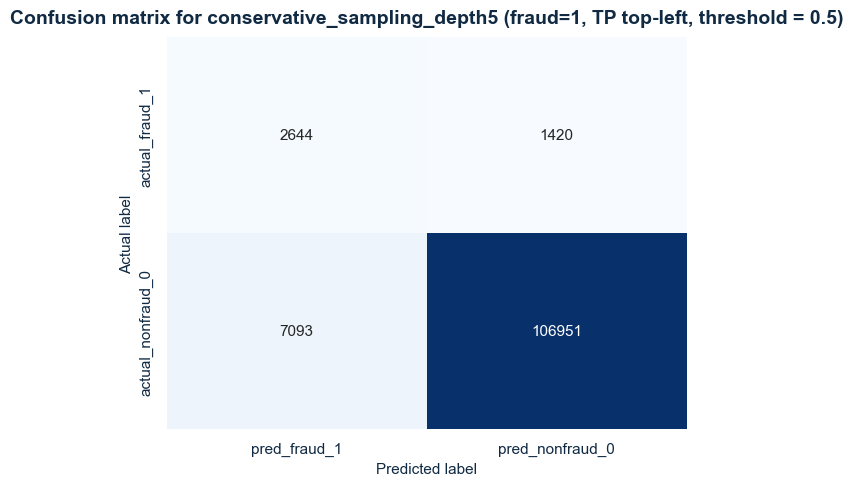

,threshold,true_positive,false_negative,false_positive,true_negative,recall,precision,false_positive_rate,predicted_fraud_rate
0,0.5000,2644,1420,7093,106951,0.6506,0.2715,0.0622,0.0824
1,0.5500,2482,1582,5632,108412,0.6107,0.3059,0.0494,0.0687
2,0.6000,2346,1718,4297,109747,0.5773,0.3532,0.0377,0.0562
3,0.6500,2187,1877,3303,110741,0.5381,0.3984,0.0290,0.0465
4,0.7000,2027,2037,2412,111632,0.4988,0.4566,0.0211,0.0376
5,0.7500,1845,2219,1698,112346,0.4540,0.5207,0.0149,0.0300


In [10]:
best_valid_scores = pd.Series(final_selected_result["valid_scores"], index=data_bundle.x_valid.index)
y_valid_series = pd.Series(data_bundle.y_valid, index=data_bundle.x_valid.index)

def summarize_threshold(scores, y_true, threshold):
    pred = (scores >= threshold).astype(int)
    tn = int(((y_true == 0) & (pred == 0)).sum())
    fp = int(((y_true == 0) & (pred == 1)).sum())
    fn = int(((y_true == 1) & (pred == 0)).sum())
    tp = int(((y_true == 1) & (pred == 1)).sum())
    return {
        "threshold": float(threshold),
        "true_positive": tp,
        "false_negative": fn,
        "false_positive": fp,
        "true_negative": tn,
        "recall": tp / (tp + fn) if (tp + fn) else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "predicted_fraud_rate": pred.mean(),
    }

base_summary = summarize_threshold(best_valid_scores, y_valid_series, threshold=0.5)
confusion_frame = pd.DataFrame(
    [[base_summary["true_positive"], base_summary["false_negative"]], [base_summary["false_positive"], base_summary["true_negative"]]],
    index=["actual_fraud_1", "actual_nonfraud_0"],
    columns=["pred_fraud_1", "pred_nonfraud_0"],
)

display(
    pd.DataFrame(
        [
            {"item": "model", "value": final_selected_row["label"]},
            {"item": "positive_class", "value": "1 = fraud"},
            {"item": "threshold", "value": 0.5},
            {"item": "true_negative", "value": base_summary["true_negative"]},
            {"item": "false_positive", "value": base_summary["false_positive"]},
            {"item": "false_negative", "value": base_summary["false_negative"]},
            {"item": "true_positive", "value": base_summary["true_positive"]},
        ]
    ).style.hide(axis="index")
)

business_summary = pd.DataFrame([base_summary])[
    [
        "threshold",
        "true_positive",
        "false_negative",
        "false_positive",
        "true_negative",
        "recall",
        "precision",
        "false_positive_rate",
        "predicted_fraud_rate",
    ]
]
display(business_summary.style.hide(axis="index"))
display(confusion_frame)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_frame, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion matrix for {final_selected_row['label']} (fraud=1, TP top-left, threshold = 0.5)")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

threshold_grid = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]
threshold_review = pd.DataFrame(
    [summarize_threshold(best_valid_scores, y_valid_series, threshold=value) for value in threshold_grid]
)[
    [
        "threshold",
        "true_positive",
        "false_negative",
        "false_positive",
        "true_negative",
        "recall",
        "precision",
        "false_positive_rate",
        "predicted_fraud_rate",
    ]
]
display(threshold_review)
